# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Alfi Syahrin
- **Email:** alfisyahrin2421@gmail.com
- **ID Dicoding:** CDCC319D6Y1274

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana perbandingan tren rata-rata peminjaman sepeda antar musim dari tahun 2011 ke 2012?
- **Pertanyaan 2:** Bagaimana perubahan tren peminjaman oleh pengguna *casual* dan *registered* pada hari kerja vs hari libur dari tahun 2011 ke tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("data/day.csv")
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset telah berhasil dimuat ke dalam dua DataFrame: `day_df` (berisi data agregasi harian) dan `hour_df` (berisi data agregasi per jam).
- Kedua tabel memiliki kolom yang merepresentasikan data yang sama, hanya berbeda pada tingkat kedetailan waktu, satu berisi data per hari dan lainnya berisi data per jam.

### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
print("\nJumlah Missing Values:")
day_df.isna().sum()


Jumlah Missing Values:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("\nJumlah Duplikasi:", day_df.duplicated().sum())


Jumlah Duplikasi: 0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
print("\nJumlah Missing Values:", hour_df.isna().sum())


Jumlah Missing Values: instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [10]:
print("\nJumlah Duplikasi:", hour_df.duplicated().sum())


Jumlah Duplikasi: 0


In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- **Missing Value & Duplikasi:** Tidak ditemukan *missing values* maupun duplikasi data pada `day_df` dan `hour_df`. Data sudah cukup bersih.
- **Tipe Data:** Kolom tanggal (`dteday`) masih menggunakan tipe `object` (string) dan harus diubah menjadi `datetime`.
- **Representasi Kategori:** Kolom kategorikal seperti `season`, `weathersit`, `workingday`, dan `yr` (tahun) masih menggunakan representasi angka. Ini perlu diubah menjadi label teks agar mempermudah analisis dan visualisasi.

### Cleaning Data

In [12]:

season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weathersit_mapping = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
workingday_mapping = {0: 'Weekend/Holiday', 1: 'Working Day'}
yr_mapping = {0: '2011', 1: '2012'}


In [13]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
day_df['season'] = day_df['season'].map(season_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weathersit_mapping)
day_df['workingday'] = day_df['workingday'].map(workingday_mapping)
day_df['yr'] = day_df['yr'].map(yr_mapping)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,Weekend/Holiday,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,Weekend/Holiday,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,Working Day,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,Working Day,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,Working Day,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    object        
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [15]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weathersit_mapping)
hour_df['workingday'] = hour_df['workingday'].map(workingday_mapping)
hour_df['yr'] = hour_df['yr'].map(yr_mapping)

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,0,6,Weekend/Holiday,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,6,Weekend/Holiday,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,6,Weekend/Holiday,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,6,Weekend/Holiday,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,6,Weekend/Holiday,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [16]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  object        
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- **Tipe Data:** Kolom `dteday` telah berhasil dikonversi menjadi format `datetime`.
- **Label Kategori:** Kolom `season`, `weathersit`, `workingday`, dan `yr` telah diubah dari angka menjadi teks deskriptif (contoh: yr 0 menjadi '2011', yr 1 menjadi '2012'). Perubahan ini membuat data jauh lebih mudah dibaca dan divisualisasikan.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data `day_df` dan `hour_df`
melihat pola rata-rata penyewaan sepeda berdasarkan musim, membandingkan tipe pengguna pada hari kerja dan libur, serta melihat tren jam sibuk.

In [17]:
#  Eksplorasi rata-rata penyewaan berdasarkan musim
print("Rata-rata penyewaan berdasarkan musim:")
day_df.groupby(by="season")["cnt"].mean().sort_values(ascending=False)

Rata-rata penyewaan berdasarkan musim:


,cnt
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


In [18]:
#  Eksplorasi perbandingan pengguna berdasarkan hari kerja/libur
print("\nRata-rata penyewaan Casual vs Registered:")
day_df.groupby(by="workingday")[["casual", "registered"]].mean()


Rata-rata penyewaan Casual vs Registered:


,casual,registered
workingday,,
Weekend/Holiday,1371.134199,2959.034632
Working Day,606.570000,3978.250000


In [19]:
#  Eksplorasi jam dengan penyewaan tertinggi
print("\n5 Jam dengan rata-rata penyewaan tertinggi:")
hour_df.groupby(by="hr")["cnt"].mean().sort_values(ascending=False).head()


5 Jam dengan rata-rata penyewaan tertinggi:


,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


**Insight:**
- **Tren Tahunan & Musim:** Terdapat peningkatan rata-rata penyewaan sepeda secara keseluruhan dari tahun 2011 ke 2012. Musim gugur (*Fall*) secara konsisten mencatatkan rata-rata penyewaan tertinggi.
- **Tipe Pengguna:** Pengguna terdaftar (*Registered*) mendominasi angka peminjaman pada hari kerja, sedangkan pengguna biasa (*Casual*) lebih banyak melakukan peminjaman pada hari libur atau akhir pekan. Pola ini terlihat konsisten baik di tahun 2011 maupun 2012.
- **Jam Sibuk:** Waktu dengan rata-rata penyewaan tertinggi berada pada pukul 17:00 dan 18:00, yang mengindikasikan tingginya penggunaan untuk pulang kerja atau sekolah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan tren rata-rata peminjaman sepeda antar musim dari tahun 2011 ke 2012?

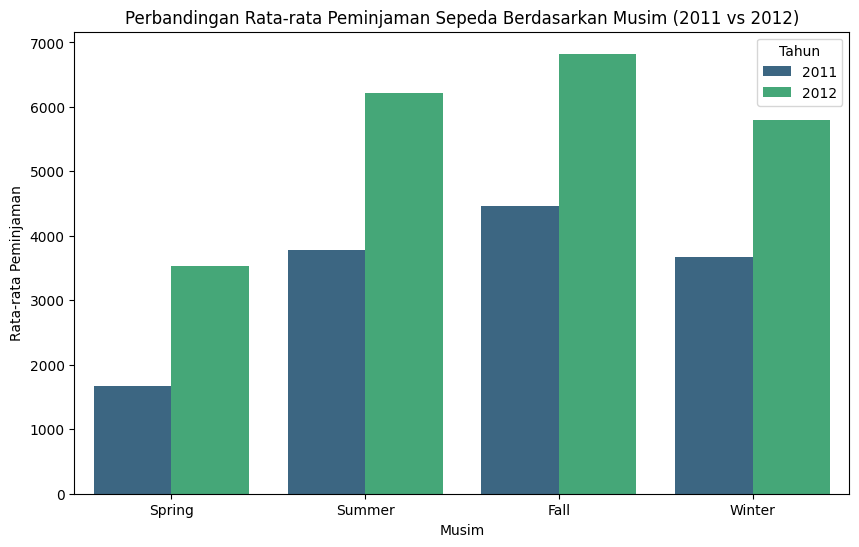

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='season',
    y='cnt',
    hue='yr',
    data=day_df,
    errorbar=None,
    palette='viridis'
)
plt.title('Perbandingan Rata-rata Peminjaman Sepeda Berdasarkan Musim (2011 vs 2012)')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Peminjaman')
plt.legend(title='Tahun')
plt.show()

### Pertanyaan 2: Bagaimana perubahan tren peminjaman oleh pengguna *casual* dan *registered* pada hari kerja vs hari libur dari tahun 2011 ke tahun 2012?

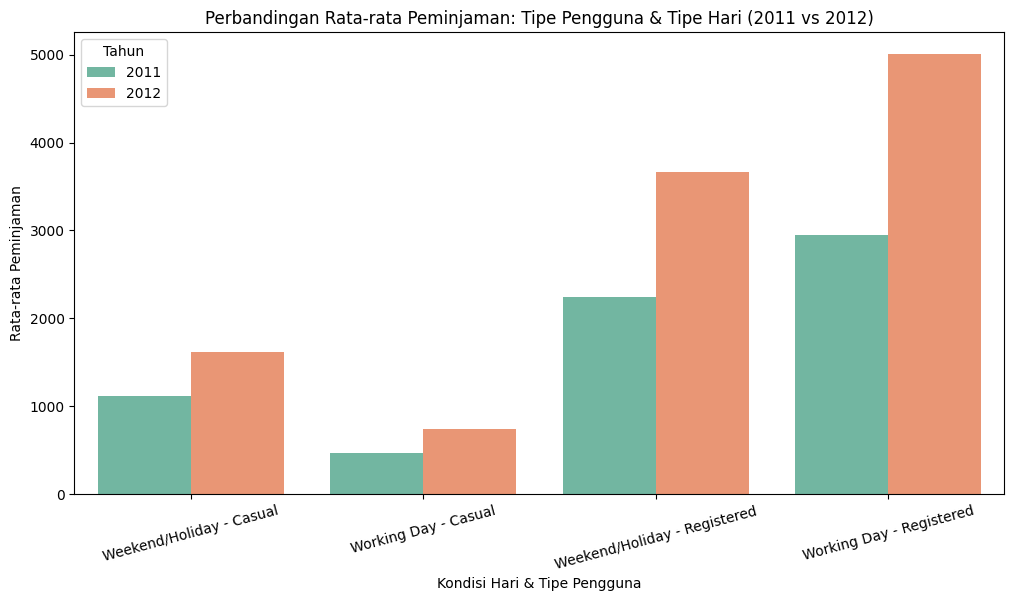

In [21]:
user_pattern = day_df.groupby(['yr', 'workingday'])[['casual', 'registered']].mean().reset_index()
user_pattern_melted = user_pattern.melt(id_vars=['yr', 'workingday'], var_name='user_type', value_name='count')
user_pattern_melted['day_user'] = user_pattern_melted['workingday'] + " - " + user_pattern_melted['user_type'].str.capitalize()

plt.figure(figsize=(12, 6))
sns.barplot(
    x='day_user',
    y='count',
    hue='yr',
    data=user_pattern_melted,
    palette='Set2'
)
plt.title('Perbandingan Rata-rata Peminjaman: Tipe Pengguna & Tipe Hari (2011 vs 2012)')
plt.xlabel('Kondisi Hari & Tipe Pengguna')
plt.ylabel('Rata-rata Peminjaman')
plt.xticks(rotation=15)
plt.legend(title='Tahun')
plt.show()

**Insight:**

**Pertanyaan 1:**
- Selama periode 2011 hingga 2012, terjadi tren peningkatan rata-rata peminjaman sepeda di semua musim.
- Musim gugur (*Fall*) konsisten menjadi musim dengan rata-rata peminjaman harian tertinggi di kedua tahun tersebut.
- Musim semi (*Spring*) memiliki rata-rata peminjaman terendah, kemungkinan karena cuaca yang belum cukup hangat di awal tahun.

**Pertanyaan 2:**
- Terdapat peningkatan jumlah rata-rata penyewaan dari tahun 2011 ke 2012 pada kedua kelompok pengguna.
- **Pengguna Registered:** Rata-rata penyewaan melonjak drastis pada hari kerja (*Working Day*), yang menunjukkan bahwa mereka menjadikan sepeda sebagai alat transportasi rutin.
- **Pengguna Casual:** Rata-rata penyewaan lebih tinggi pada akhir pekan/hari libur (*Weekend/Holiday*), mengindikasikan bahwa kelompok ini menyewa sepeda utamanya untuk tujuan rekreasi.

## Analisis Lanjutan (Opsional)

In [22]:
# Menerapkan Clustering (Binning)
# Membagi rentang nilai 'cnt' menjadi 3 kategori interval yang sama besar
day_df['rental_category'] = pd.cut(day_df['cnt'], bins=3, labels=['Sepi', 'Normal', 'Ramai'])

# Melihat jumlah hari pada masing-masing kategori
print("Distribusi Kategori Penyewaan Harian:")
day_df['rental_category'].value_counts()

Distribusi Kategori Penyewaan Harian:


,count
rental_category,
Normal,370
Ramai,194
Sepi,167


/tmp/ipykernel_2507/821077887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=day_df, x='rental_category', palette='magma', order=['Sepi', 'Normal', 'Ramai'])


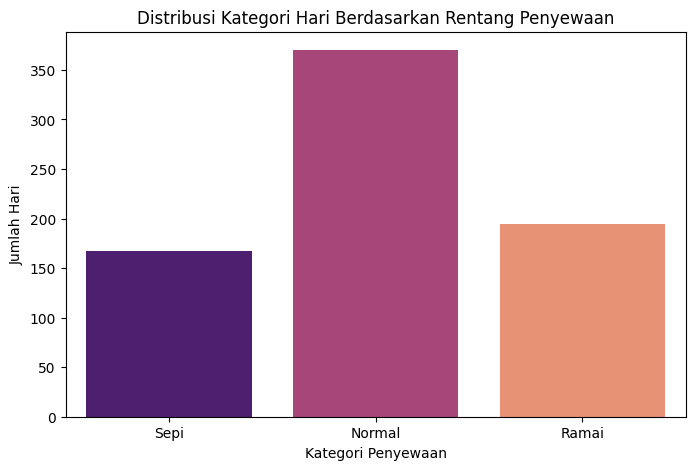

In [23]:
# Visualisasi hasil clustering
plt.figure(figsize=(8, 5))
sns.countplot(data=day_df, x='rental_category', palette='magma', order=['Sepi', 'Normal', 'Ramai'])
plt.title('Distribusi Kategori Hari Berdasarkan Rentang Penyewaan')
plt.xlabel('Kategori Penyewaan')
plt.ylabel('Jumlah Hari')
plt.show()

**Insight:**
- Analisis lanjutan dilakukan menggunakan teknik **Clustering (Binning)** dengan membagi rentang nilai total penyewaan harian (`cnt`) ke dalam 3 kelompok.
- Kategori dibagi menjadi **Sepi**, **Normal**, dan **Ramai** berdasarkan rentang volume penyewaan.
- Dari hasil distribusi, kita dapat melihat mayoritas hari masuk ke dalam kategori apa. Ini membantu operasional bisnis dalam menentukan standar minimum armada sepeda yang harus disiapkan pada hari-hari biasa.

## Conclusion

**1. Conclusion Pertanyaan 1 (Pengaruh Musim)**
Berdasarkan data 2011-2012, penyewaan tertinggi terjadi di musim gugur (*Fall*) dan terendah di musim semi (*Spring*), dengan tren pertumbuhan positif di semua musim.
* **Rekomendasi:** Maksimalkan ketersediaan sepeda menjelang musim gugur. Gunakan musim semi untuk *maintenance* armada dan berikan promo diskon untuk menstimulasi penyewaan di masa *low-season*.

**2. Conclusion Pertanyaan 2 (Pola Tipe Pengguna)**
Pengguna *Registered* mendominasi hari kerja untuk alat transportasi rutin, sedangkan *Casual* dominan di hari libur untuk rekreasi. Keduanya mengalami peningkatan dari tahun sebelumnya.
* **Rekomendasi:** Berikan program *reward* (misal: "Bike to Work Point") untuk mempertahankan pengguna *Registered* di hari kerja. Tawarkan paket langganan akhir pekan untuk menarik pengguna *Casual* menjadi *Registered*.

**3. Conclusion Analisis Lanjutan (Clustering - Binning)**
Hasil pengelompokan volume penyewaan harian menunjukkan mayoritas hari berkinerja "Normal" (370 hari), diikuti "Ramai" (194 hari) dan "Sepi" (167 hari).
* **Rekomendasi:** Jadikan rata-rata penyewaan di hari "Normal" sebagai patokan operasional standar harian. Siapkan sistem logistik penambahan armada secara dinamis saat hari diprediksi "Ramai" (seperti saat musim gugur atau hari libur panjang).

In [24]:
day_df.to_csv("dashboard/clean_day.csv", index=False)
hour_df.to_csv("dashboard/clean_hour.csv", index=False)